# **Project Name**    -  Paisabazaar Banking Fraud Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual

# **Project Summary**

This project focuses on conducting **Exploratory Data Analysis (EDA)** on Paisabazaar’s customer credit dataset to understand **what separates Good, Standard, and Poor credit profiles** in a practical and measurable way.

In real lending and credit evaluation, relying on a few simple metrics is risky — because creditworthiness is shaped by a combination of **repayment behavior, debt burden, credit exposure, and financial stability**. Through this EDA, the goal was to uncover the most influential indicators that can support **more consistent credit assessment**, reduce risk-driven losses, and enable smarter product recommendations.

**Data Understanding & Preparation**

The dataset contains **100,000 customer records** with **28 features**, covering demographic, financial, and behavioral attributes, with **Credit_Score** as the target variable. Basic validation confirmed **no missing values** and **no duplicate records**, ensuring a strong foundation for analysis. Data wrangling was focused on making the dataset analysis-ready by correcting data types, treating identifiers properly, cleaning the Type_of_Loan variable (multi-valued text issue), and creating structured features like Num_Loan_Types.

**EDA & Visualization Approach**

The analysis followed a structured **UBM framework**:

- **Univariate** to understand customer distribution and feature behavior

- **Bivariate** to identify which variables change significantly across credit score groups

- **Multivariate** to validate patterns using combined risk indicators

More than **20 business-relevant visualizations** were created using boxplots, histograms, countplots, scatter plots, line charts, and correlation heatmaps to connect customer attributes with credit score outcomes.

**Key Findings**

The largest customer segment falls under **Standard** (~53%), making it the biggest opportunity area to improve approvals while keeping risk under control.

**Payment behavior is the clearest differentiator** — customers with frequent delayed payments strongly align with the Poor credit score group (median delays are much higher than the Good group).

**Debt stress indicators** such as higher outstanding debt and multiple active loans are strongly linked with weaker credit profiles, showing that credit burden plays a key role in score decline.

**Credit mix quality** shows strong separation — customers with a Good credit mix are mostly in the Good score category, while a Bad mix is heavily concentrated in Poor.

**Income provides context but is not sufficient alone** — high-income customers still appear in Standard and Poor groups when repayment behavior is weak, meaning income should not be used as a standalone approval signal.

Overall, this project highlights the most reliable drivers behind credit score categories and supports Paisabazaar in improving risk-aware decision-making, maintaining **consistent credit evaluation**, and enabling **more relevant product recommendations** across customer segments.

# **GitHub Link**

Provide your GitHub Link here.

# **Problem Statement**


- Paisabazaar has access to detailed customer credit and financial data, but lacks clear visibility into which customer behaviors and financial attributes differentiate good, average, and poor credit profiles.

- This project explores and analyzes credit-related data to identify the key factors associated with different credit score categories, supporting more consistent credit assessment and risk-aware decision-making.

# **Business Objective**

- To analyze customer credit and financial data to understand how behavioral and financial attributes vary across different credit score categories.

- To identify the key factors associated with good, average, and poor credit profiles, supporting more consistent and informed credit assessment decisions.

- To provide data-driven insights that can assist Paisabazaar’s risk and credit teams in improving credit evaluation and product recommendations.

## **Know Your Data**

### Import Required Libraries

In [ ]:
# Core data handling libraries
import pandas as pd
import numpy as np

# File and system handling
import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

### Dataset Loading

In [ ]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define project and data paths
PROJECT_PATH = '/content/drive/MyDrive/Paisabazaar_Project'
DATA_PATH = f'{PROJECT_PATH}/Data'

In [ ]:
# Load dataset
data = pd.read_csv(f'{DATA_PATH}/dataset.csv')

### Dataset First View

In [ ]:
# Preview first few records
data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


### Dataset Rows & Columns count

In [ ]:
# Check dataset shape
data.shape

(100000, 28)

### Dataset Information

In [ ]:
# Overview of data types and non-null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

#### Duplicate Values

In [ ]:
# Check number of duplicate records
data.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Check missing values per column
data.isnull().sum()

,0
ID,0
Customer_ID,0
Month,0
Name,0
Age,0
SSN,0
Occupation,0
Annual_Income,0
Monthly_Inhand_Salary,0
Num_Bank_Accounts,0


### What did you know about your dataset?

- The dataset contains 100,000 customer records and 28 variables, providing sufficient scale for exploratory analysis.

- There are no missing values and no duplicate records, indicating strong data completeness and consistency.

- The data includes a mix of demographic, financial, and behavioral attributes, along with a categorical target variable, Credit_Score.

- Several variables have inappropriate data types (e.g., integer-based fields stored as floats and identifier fields treated as numeric), requiring data type correction before further analysis.

## **Understanding Your Variables**

In [ ]:
# View all column names
data.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [ ]:
# Statistical summary of numerical variables
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,100000.0,8.063150e+04,4.330149e+04,5634.000000,4.313275e+04,8.063150e+04,1.181302e+05,1.556290e+05
Customer_ID,100000.0,2.598267e+04,1.434054e+04,1006.000000,1.366450e+04,2.577700e+04,3.838500e+04,5.099900e+04
Month,100000.0,4.500000e+00,2.291299e+00,1.000000,2.750000e+00,4.500000e+00,6.250000e+00,8.000000e+00
Age,100000.0,3.331634e+01,1.076481e+01,14.000000,2.400000e+01,3.300000e+01,4.200000e+01,5.600000e+01
SSN,100000.0,5.004617e+08,2.908267e+08,81349.000000,2.451686e+08,5.006886e+08,7.560027e+08,9.999934e+08
Annual_Income,100000.0,5.050512e+04,3.829942e+04,7005.930000,1.934297e+04,3.699971e+04,7.168347e+04,1.799873e+05
Monthly_Inhand_Salary,100000.0,4.197271e+03,3.186432e+03,303.645417,1.626594e+03,3.095905e+03,5.957715e+03,1.520463e+04
Num_Bank_Accounts,100000.0,5.368820e+00,2.593314e+00,0.000000,3.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Num_Credit_Card,100000.0,5.533570e+00,2.067098e+00,0.000000,4.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Interest_Rate,100000.0,1.453208e+01,8.741330e+00,1.000000,7.000000e+00,1.300000e+01,2.000000e+01,3.400000e+01


In [ ]:
# Summary of categorical variables
data.describe(include='object').T

,count,unique,top,freq
Name,100000,10128,Jessicad,48
Occupation,100000,15,Lawyer,7096
Type_of_Loan,100000,6261,No Data,11408
Credit_Mix,100000,3,Standard,45848
Payment_of_Min_Amount,100000,3,Yes,52326
Payment_Behaviour,100000,6,Low_spent_Small_value_payments,28616
Credit_Score,100000,3,Standard,53174


### Variables Description


🧾 Columns Description
Customer & Demographic Information

- `Customer_ID` – Unique identifier for each customer.

- `Age` – Age of the customer.

- `Occupation` – Employment type or occupation category.

- `Annual_Income` – Reported annual income of the customer.

Credit & Financial Attributes

- `Num_Bank_Accounts` – Number of active bank accounts held.

- `Num_Credit_Card` – Number of credit cards owned.

- `Interest_Rate` – Interest rate applied to credit accounts.

- `Num_of_Loan` – Total number of active loans.

- `Outstanding_Debt` – Total outstanding debt amount.

- `Credit_Utilization_Ratio` – Ratio of credit used to total credit limit.

Behavioral & Payment Information

- `Num_of_Delayed_Payment` – Number of delayed payments.

- `Delay_from_due_date` – Average delay from the payment due date (in days).

- `Payment_Behaviour` – Observed payment behavior pattern.

- `Payment_of_Min_Amount` – Indicates whether minimum payment was made.

Credit History & Score

- `Credit_History_Age` – Length of the customer’s credit history.

- `Credit_Score` – Creditworthiness category (Good, Standard, Poor).

### Check Unique Values for each variable.

In [ ]:
# # Check number of unique values for each column
data.nunique().sort_values(ascending=False)

,0
ID,100000
Credit_Utilization_Ratio,100000
Monthly_Balance,98494
Monthly_Inhand_Salary,13241
SSN,12500
Customer_ID,12500
Annual_Income,12488
Amount_invested_monthly,12261
Outstanding_Debt,12203
Total_EMI_per_month,11890


In [ ]:
# Inspect unique values in important categorical columns
categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(data[col].unique())


Unique values in Name:
['Aaron Maashoh' 'Rick Rothackerj' 'Langep' ... 'Chris Wickhamm'
 'Sarah McBridec' 'Nicks']

Unique values in Occupation:
['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant' 'Musician'
 'Mechanic' 'Writer' 'Architect']

Unique values in Type_of_Loan:
['Auto Loan, Credit-Builder Loan, Personal Loan, and Home Equity Loan'
 'Credit-Builder Loan' 'Auto Loan, Auto Loan, and Not Specified' ...
 'Home Equity Loan, Auto Loan, Auto Loan, and Auto Loan'
 'Payday Loan, Student Loan, Mortgage Loan, and Not Specified'
 'Personal Loan, Auto Loan, Mortgage Loan, Student Loan, and Student Loan']

Unique values in Credit_Mix:
['Good' 'Standard' 'Bad']

Unique values in Payment_of_Min_Amount:
['No' 'NM' 'Yes']

Unique values in Payment_Behaviour:
['High_spent_Small_value_payments' 'Low_spent_Large_value_payments'
 'Low_spent_Medium_value_payments' 'Low_spent_Small_value_payments'
 'High_spent_Medium_v

## **Data Wrangling**

In [ ]:
# Make a copy to preserve raw data
df = data.copy()

Data Type Corrections

In [ ]:
# Convert identifier columns to object
identifier_cols = ['Customer_ID','ID','SSN']

for col in identifier_cols:
    df[col] = df[col].astype(str)

In [ ]:
# Convert Age from float to integer
df['Age'] = df['Age'].astype(int)
df['Credit_History_Age'] = df['Credit_History_Age'].astype(int)

In [ ]:
# List of count-based columns
count_cols = [
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Num_of_Loan',
    'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries'
]

for col in count_cols:
    df[col] = df[col].astype(int)

In [ ]:
# Re-check data types after conversion
df.dtypes

,0
ID,object
Customer_ID,object
Month,int64
Name,object
Age,int64
SSN,object
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64


In [ ]:
# Function to clean repeated loan types within a row
def clean_type_of_loan(value):
    if pd.isna(value):
        return value

    # Normalize separators and split
    loans = value.replace(' and ', ', ').split(',')

    # Strip spaces and remove empty values
    loans = [loan.strip() for loan in loans if loan.strip()]

    # Remove duplicates while preserving order
    loans = list(dict.fromkeys(loans))

    return ', '.join(loans)

# Apply cleaning
df['Type_of_Loan'] = df['Type_of_Loan'].apply(clean_type_of_loan)


In [ ]:
# Number of distinct loan types per customer
df['Num_Loan_Types'] = df['Type_of_Loan'].apply(
    lambda x: len(x.split(', ')) if pd.notna(x) else 0
)

In [ ]:
# Re-check data types
df.dtypes

,0
ID,object
Customer_ID,object
Month,int64
Name,object
Age,int64
SSN,object
Occupation,object
Annual_Income,float64
Monthly_Inhand_Salary,float64
Num_Bank_Accounts,int64


In [ ]:
# Ensure dataset shape is unchanged
df.shape

(100000, 29)

### What all manipulations have you done and insights you found?

The following data wrangling steps were performed to prepare the dataset for analysis:

- Created a copy of the original dataset to ensure the raw data remained unchanged.

- Fixed data type issues across several columns:

   - Converted identifier columns (Customer_ID, ID, SSN) to object type, as these are identifiers and should not be treated as numeric values.

  - Converted Age and Credit_History_Age from float to integer, since they represent whole-number values.

  - Converted count-based columns (Num_Bank_Accounts, Num_Credit_Card, Num_of_Loan, Num_of_Delayed_Payment, Num_Credit_Inquiries) from float to integer for correct numerical interpretation.

- Cleaned the Type_of_Loan column, which contained multiple loan types in a single field:

   - Standardized text formatting and separators.

   - Removed duplicate loan types within the same record.

- Created a new column, Num_Loan_Types, to represent the number of distinct loan types held by each customer.

- Verified the dataset after wrangling to confirm that data types were corrected and the overall dataset size remained unchanged.

Dataset is now clean, consistent, and ready for EDA.

## **Data Visualisation**
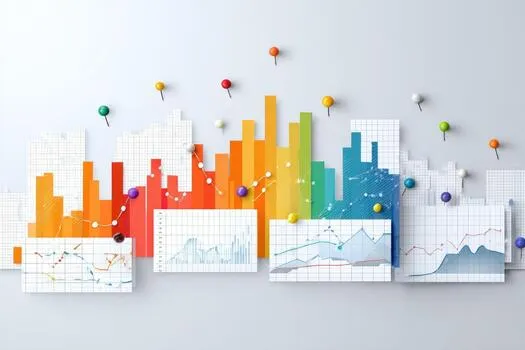

## Univariate Analysis

## Chart - 1
#### Count Plot : Credit Score Distribution

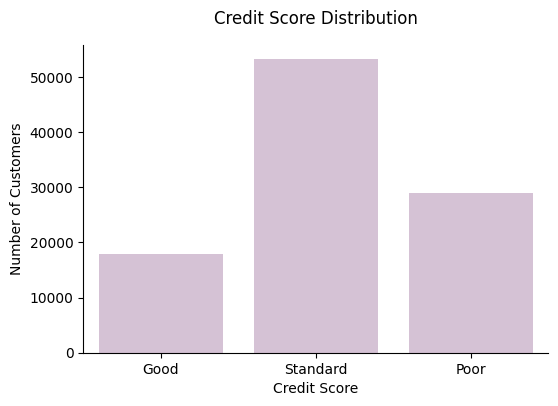

In [ ]:
# Plot distribution of credit score categories

# To set a figure size
plt.figure(figsize=(6, 4))

# Create count plot to show number of customers in each credit score category
sns.countplot(data=df, x='Credit_Score', color='thistle')

# Titles and axis labels
plt.title('Credit Score Distribution', pad=15)
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- A count plot is suitable because it clearly shows how customers are distributed across the different credit score categories.

#####  What is/are the insight(s) found from the chart?

- The Standard category has the highest number of customers, followed by Poor, while Good has the lowest count.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this helps Paisabazaar focus risk and product strategies on the largest customer group (Standard) while closely monitoring the Poor group for higher credit risk.

## Chart - 2
#### Histogram : Age Distribution

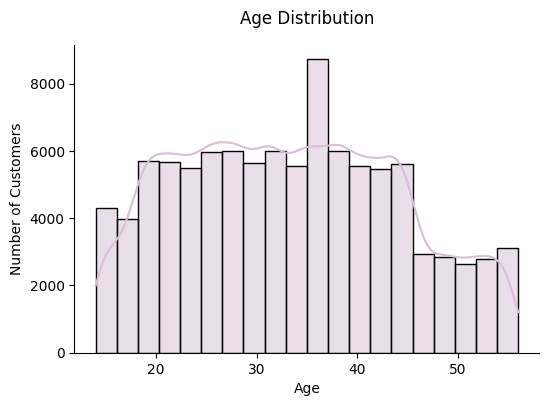

In [ ]:
# Plot age distribution of customers

# To set a figure size
plt.figure(figsize=(6, 4))

# Create histogram with KDE to understand age spread and density
sns.histplot(df['Age'], bins=20, kde=True, color='thistle')

# Titles and axis labels
plt.title('Age Distribution', pad=15)
plt.xlabel('Age')
plt.ylabel('Number of Customers')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- A histogram is best to see how customer ages are spread across the dataset.

#####  What is/are the insight(s) found from the chart?

- Most customers are between 20 to 45 years, with fewer customers in very young or older age groups.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight helps Paisabazaar understand which age group forms the majority of customers, so the business can focus credit policies and product decisions around the main customer base instead of making assumptions.

## Chart - 3
#### Histogram : Annual Income Distribution

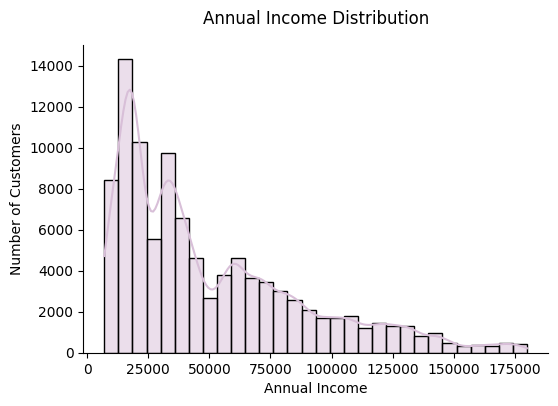

In [ ]:

# Plot annual income distribution of customers

# To set a figure size
plt.figure(figsize=(6, 4))

# Create histogram with KDE to understand income spread and density
sns.histplot(df['Annual_Income'], bins=30, kde=True, color='thistle')

# Titles and axis labels
plt.title('Annual Income Distribution', pad=15)
plt.xlabel('Annual Income')
plt.ylabel('Number of Customers')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()


#####  Why did you pick the specific chart?

- A histogram helps understand how customer annual income is distributed and whether income levels are evenly spread or skewed.

#####  What is/are the insight(s) found from the chart?

- Most customers earn around 10,000 to 50,000 annually, while only a small portion earn above 100,000, showing a clear right-skewed income distribution.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight helps Paisabazaar set realistic income-based credit limits and risk checks for the majority of customers, instead of designing policies around a small group of high-income outliers.

## Chart - 4
#### Histogram : Outstanding Debt Distribution

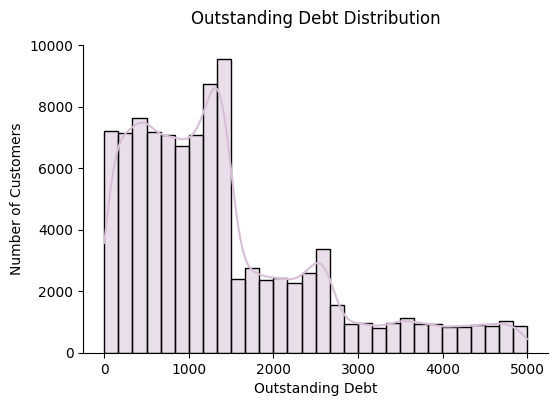

In [ ]:
# Plot outstanding debt distribution of customers

# To set a figure size
plt.figure(figsize=(6, 4))

# Create histogram with KDE to understand debt spread and density
sns.histplot(df['Outstanding_Debt'], bins=30, kde=True, color='thistle')

# Titles and axis labels
plt.title('Outstanding Debt Distribution', pad=15)
plt.xlabel('Outstanding Debt')
plt.ylabel('Number of Customers')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- A histogram helps to understand how outstanding debt is spread across customers and whether most customers fall in low or high debt ranges.

#####  What is/are the insight(s) found from the chart?

- Most customers have outstanding debt between 0 to 1500, while only a small number of customers have debt above 3000, showing a right-skewed pattern.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, because customers with very high debt can be treated as a higher-risk segment, so Paisabazaar can be more careful with approvals or credit limits for them.

## Chart - 5
#### Histogram : Credit Utilization Ratio Distribution

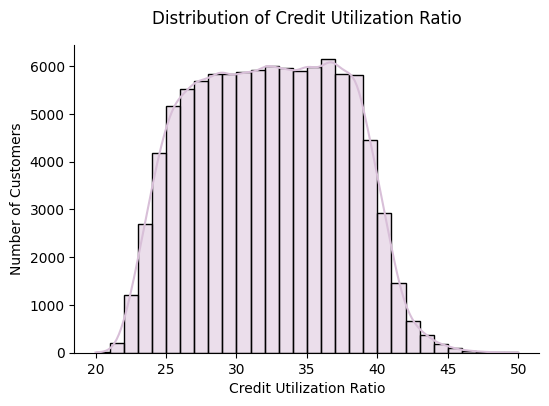

In [ ]:

plt.figure(figsize=(6, 4))
sns.histplot(df['Credit_Utilization_Ratio'], bins=30, kde=True, color='thistle')

plt.title('Distribution of Credit Utilization Ratio', pad=15)
plt.xlabel('Credit Utilization Ratio')
plt.ylabel('Number of Customers')

sns.despine()
plt.show()


##### 1. Why did you pick the specific chart?

A histogram is used to understand how credit utilization ratios are distributed across customers.

##### 2. What is/are the insight(s) found from the chart?

The distribution is almost bell-shaped, with the KDE curve peaking around 30–38, which shows most customers have moderate credit utilization and fewer customers fall at the extreme low or high ends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight helps Paisabazaar identify high credit utilization customers early and apply better risk controls to reduce default chances.

## Chart - 6
####Count plot : Delayed Payments Distribution

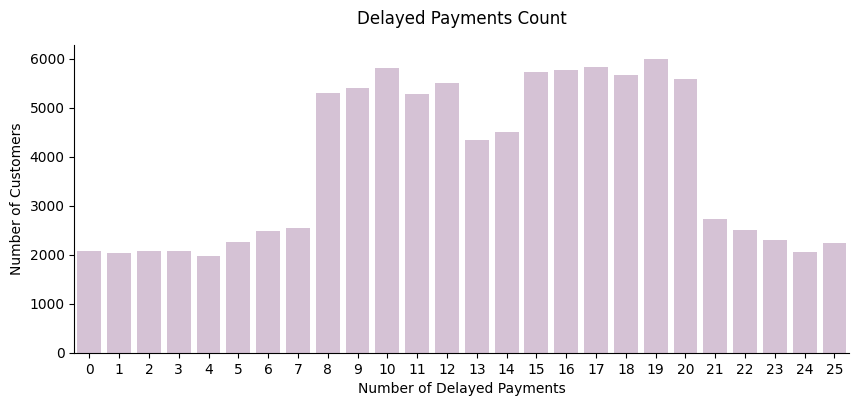

In [ ]:
# Plot count distribution of number of delayed payments

# To set a figure size
plt.figure(figsize=(10, 4))

# Create count plot to show how many customers fall into each delayed payment count
sns.countplot(data=df, x='Num_of_Delayed_Payment', color='thistle')

# Titles and axis labels
plt.title('Delayed Payments Count', pad=15)
plt.xlabel('Number of Delayed Payments')
plt.ylabel('Number of Customers')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- A count plot helps clearly compare how many customers fall into each delayed payment count.

#####  What is/are the insight(s) found from the chart?

- The highest number of customers have delayed payments mostly between 8 to 20, which shows payment delays are common for many customers.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight helps Paisabazaar identify customers with frequent payment delays early and improve credit risk decisions to reduce future defaults.

## Bi-variate Analysis

## Chart - 7
#### Box plot : Income vs Credit Score

A box plot visually shows the data’s spread, median, and outliers at a glance, helping you quickly understand distribution patterns.

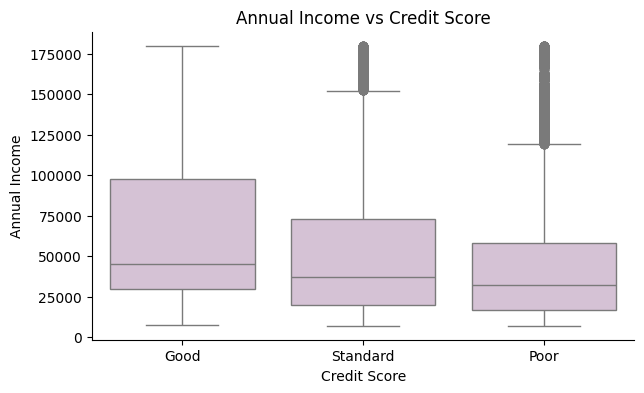

In [ ]:
# Plot annual income distribution across different credit score categories

# Set figure size
plt.figure(figsize=(7, 4))

# Create boxplot
sns.boxplot(data=df, x='Credit_Score', y='Annual_Income', color='thistle')

# Title and axis labels
plt.title('Annual Income vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Annual Income')

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#####  Why did you pick the specific chart?

This box plot helps compare the typical income level and income spread across different credit score categories.

#####  What is/are the insight(s) found from the chart?

The median income is highest for the Good category and lowest for the Poor category, but high-income outliers are still present in Standard and Poor, showing income alone does not fully explain credit score

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can create positive business impact because it helps Paisabazaar avoid approving loans only based on high income, but it may also lead to negative growth since some high-income customers with poor credit behavior could be rejected, reducing short-term loan approvals.

## Chart - 8
#### Box Plot : Outstanding Debt vs Credit Score

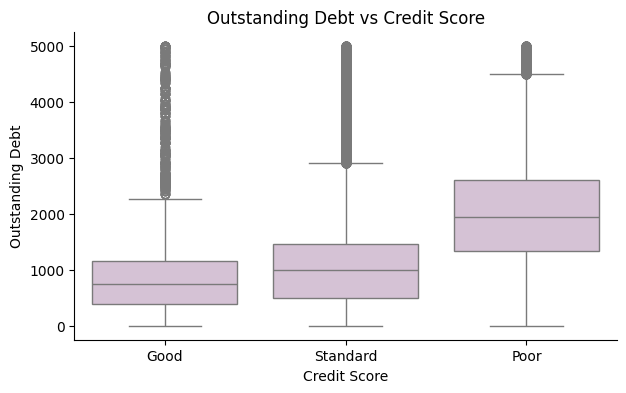

In [ ]:
# Plot outstanding debt distribution across different credit score categories

# Set figure size
plt.figure(figsize=(7, 4))

# Create plot
sns.boxplot(data=df, x='Credit_Score', y='Outstanding_Debt', color='thistle')

# Titles and axis labels
plt.title('Outstanding Debt vs Credit Score')
plt.xlabel('Credit Score')
plt.ylabel('Outstanding Debt')

# using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#####  Why did you pick the specific chart?

This box plot helps compare how outstanding debt levels vary across Good, Standard, and Poor credit score categories.

#####  What is/are the insight(s) found from the chart?

The Poor credit score group has a clearly higher typical outstanding debt (median) compared to Good and Standard, showing that higher debt is strongly linked with lower credit scores.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight supports better risk decisions by flagging high-debt customers early, but it can also reduce short-term loan approvals because stricter rules on high-debt customers may reject more applicants.

## Chart - 9
#### Box plot : Credit utilization ratio vs Credit score

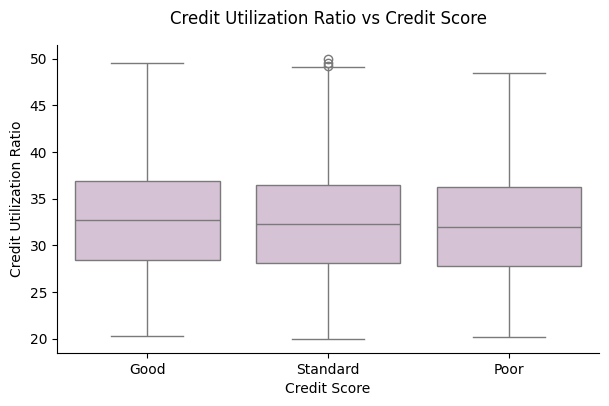

In [ ]:
# Plot credit utilization ratio distribution across different credit score categories

# To set a figure size
plt.figure(figsize=(7, 4))

# Create box plot
sns.boxplot(data=df, x='Credit_Score', y='Credit_Utilization_Ratio', color='thistle')

# Titles and axis labels
plt.title('Credit Utilization Ratio vs Credit Score', pad=15)
plt.xlabel('Credit Score')
plt.ylabel('Credit Utilization Ratio')

# Using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#####  Why did you pick the specific chart?

This box plot helps compare credit utilization levels across Good, Standard, and Poor credit score categories.

#####  What is/are the insight(s) found from the chart?

The median credit utilization ratio looks almost similar across all credit score groups, which suggests utilization alone is not strongly separating Good vs Poor customers in this dataset.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight helps Paisabazaar avoid relying only on utilization for credit decisions, but it may reduce short-term approvals if strict utilization rules are applied even when they are not strongly linked to credit score.

## Chart - 10
#### Box plot : Delayed payments vs Credit score

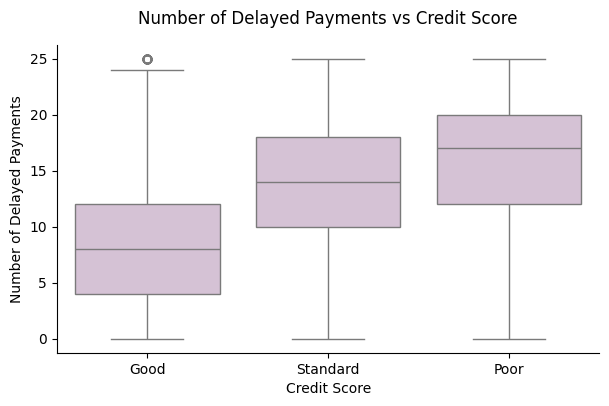

In [ ]:
# Plot number of delayed payments across different credit score categories

# To set a figure size
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Credit_Score', y='Num_of_Delayed_Payment', color='thistle')

# Titles and axis labels
plt.title('Number of Delayed Payments vs Credit Score', pad=15)
plt.xlabel('Credit Score')
plt.ylabel('Number of Delayed Payments')

# Using despine to remove right and top borders
sns.despine()

# Display the plot
plt.show()

#####  Why did you pick the specific chart?

This box plot helps compare how delayed payment counts change across different credit score categories.

#####  What is/are the insight(s) found from the chart?

Customers with Poor credit scores show a much higher typical number of delayed payments (~17–18) compared to the Good group (~7–8), making delayed payments a clear and strong signal of credit risk.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this insight can improve risk decisions by flagging customers with frequent delays, but it may reduce approvals because stricter rules on delayed payments can reject more applicants.

## Chart - 11
#### Box plot : Loans vs Credit Score

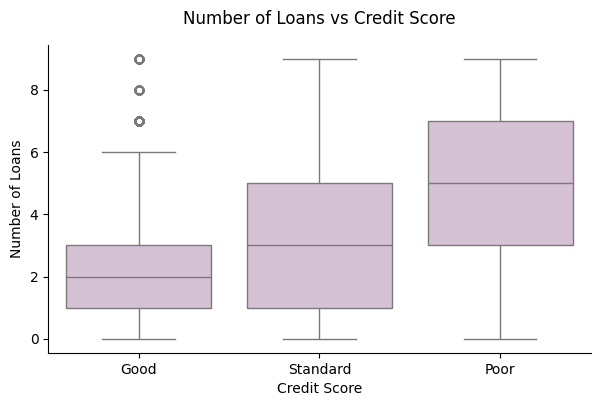

In [ ]:
# Plot number of loans across different credit score categories

# To set a figure size
plt.figure(figsize=(7, 4))

# Create plot
sns.boxplot(data=df, x='Credit_Score', y='Num_of_Loan', color='thistle')

# Titles and axis labels
plt.title('Number of Loans vs Credit Score', pad=15)
plt.xlabel('Credit Score')
plt.ylabel('Number of Loans')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()


#####  Why did you pick the specific chart?

- This box plot helps compare how the number of active loans differs across credit score categories.

#####  What is/are the insight(s) found from the chart?

- Customers with Poor credit scores typically have more loans (median around 5), compared to Good customers (median around 2), showing higher credit exposure is linked to lower credit scores.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight helps Paisabazaar control credit risk by monitoring customers with many active loans, but it may reduce approvals if stricter limits are applied to multi-loan customers.

## Chart - 12
#### Line plot : Credit Score Trend by Age

Line plots help data analysts visualize trends and patterns between two numerical variables, especially over time.

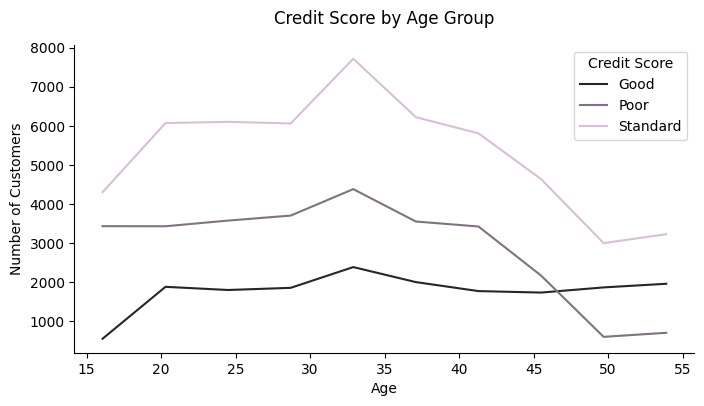

In [ ]:
# Plot credit score trend across age groups

# Create age bins to group customers into age ranges
age_bins = pd.cut(df['Age'], bins=10)

# Count customers in each age group for every credit score category
age_credit_trend = (
    df.groupby([age_bins, 'Credit_Score'])
      .size()
      .reset_index(name='count')
)

# Extract mid-point of each age bin for smooth line plotting
age_credit_trend['age_mid'] = age_credit_trend['Age'].apply(lambda x: x.mid)

# To set a figure size
plt.figure(figsize=(8, 4))

# Create line plot
sns.lineplot(
    data=age_credit_trend,
    x='age_mid',
    y='count',
    hue='Credit_Score',
    palette='dark:thistle'
)

# Titles and axis labels
plt.title('Credit Score by Age Group', pad=15)
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.legend(title='Credit Score')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- To clearly compare how Good / Standard / Poor credit score customer counts change across different age groups.

#####  What is/are the insight(s) found from the chart?

- Standard credit score customers dominate in most age groups and peak around early 30s, while Poor decreases after mid-40s and Good stays relatively stable.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this helps Paisabazaar build age-based risk strategies (e.g., stronger credit checks where Poor peaks and smarter offers where Standard is highest) to improve approvals and reduce defaults.

## Chart - 13
#### Count Plot : Credit Mix by Credit Score

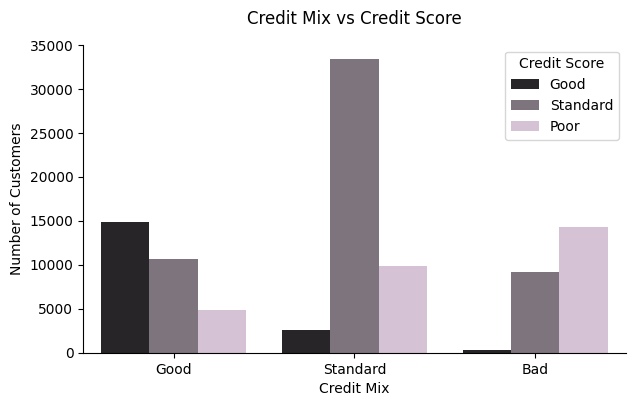

In [ ]:
# Plot credit mix distribution across different credit score categories

# To set a figure size
plt.figure(figsize=(7, 4))

# Create count plot
sns.countplot(data=df, x='Credit_Mix', hue='Credit_Score', palette='dark:thistle')

# Titles and axis labels
plt.title('Credit Mix vs Credit Score', pad=15)
plt.xlabel('Credit Mix')
plt.ylabel('Number of Customers')
plt.legend(title='Credit Score')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- This grouped bar chart helps compare how credit score categories are distributed across different credit mix levels (Good, Standard, Bad).

#####  What is/are the insight(s) found from the chart?

- Customers with a Good credit mix are mostly in the Good credit score category, while customers with a Bad credit mix are heavily concentrated in the Poor credit score category, showing credit mix is a strong differentiator.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight can improve approval quality by using credit mix as a risk signal, but it may reduce approvals if customers with bad credit mix are filtered out more strictly.

## Chart - 14
#### Count Plot : Min Payment by Credit Score

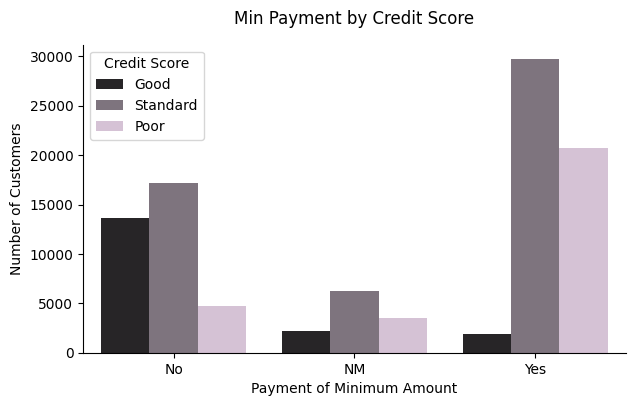

In [ ]:
# Plot minimum payment behaviour across different credit score categories

# To set a figure size
plt.figure(figsize=(7, 4))

# Create count plot
sns.countplot(data=df, x='Payment_of_Min_Amount', hue='Credit_Score', palette='dark:thistle')

# Titles and axis labels
plt.title('Min Payment by Credit Score', pad=15)
plt.xlabel('Payment of Minimum Amount')
plt.ylabel('Number of Customers')
plt.legend(title='Credit Score')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- This chart helps compare credit score categories across different minimum payment behaviours (Yes/No/NM).

#####  What is/are the insight(s) found from the chart?

- Customers who pay only the minimum amount (Yes) are mostly concentrated in Standard and Poor credit score groups, while the Good category is comparatively lower.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight can improve credit risk decisions by treating minimum-only payments as a warning signal, but it may reduce approvals if many customers fall into the risky group and stricter rules are applied.

## Chart - 15
#### Stacked Bar Chart : Credit Score % by Occupation

A 100% stacked bar plot is a chart where each bar represents a group, and the segments inside the bar show the percentage contribution of each category so that the total of every bar equals 100%.

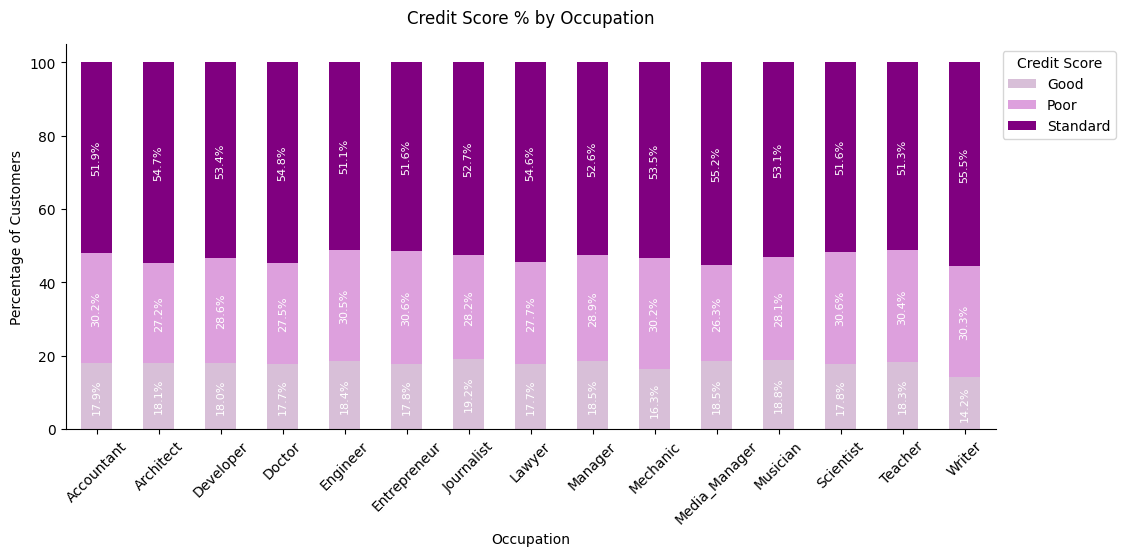

In [ ]:
# Plot credit score percentage distribution across occupations

# Create a cross-tab to calculate credit score percentage per occupation
occupation_score = pd.crosstab(df['Occupation'], df['Credit_Score'], normalize='index') * 100

# Create stacked bar chart
ax = occupation_score.plot(kind='bar', stacked=True, figsize=(12, 5),color=['thistle', 'plum', 'purple'])

# Titles and axis labels
plt.title('Credit Score % by Occupation', pad=15)
plt.xlabel('Occupation')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45)
plt.legend(title='Credit Score', loc='upper left', bbox_to_anchor=(1, 1))

# Add percentage labels on bars for better interpretation
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8, color='white', rotation=90)

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- A stacked bar chart is best to compare the proportion of Good/Standard/Poor credit scores across different occupations.

#####  What is/are the insight(s) found from the chart?

- Across most occupations, the Standard category dominates (51%–55%), while Good remains the smallest share (~14%–19%), showing occupation alone does not create major credit score separation.

#####  Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight prevents occupation-based bias and supports fair credit decisions, but relying too much on occupation can reduce approvals unnecessarily since credit score distribution looks similar across jobs.

## Chart - 16
#### Scatter Plot : Annual Income vs Outstanding Debt

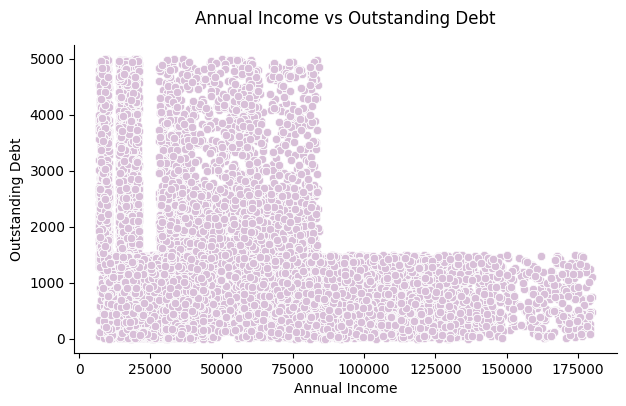

In [ ]:
# Plot relationship between annual income and outstanding debt

# To set a figure size
plt.figure(figsize=(7, 4))

# Create scatter plot
sns.scatterplot(data=df, x='Annual_Income', y='Outstanding_Debt', color='thistle')

# Titles and axis labels
plt.title('Annual Income vs Outstanding Debt', pad=15)
plt.xlabel('Annual Income')
plt.ylabel('Outstanding Debt')

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

##### Why did you pick the specific chart?

- A scatter plot is useful to check whether annual income has a direct relationship with outstanding debt levels.

##### What is/are the insight(s) found from the chart?

- There is no strong linear trend between income and debt, but high outstanding debt values are mostly seen in the low-to-mid income range (up to ~80k), while higher incomes generally show lower debt concentration.

##### Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this insight helps Paisabazaar avoid relying only on income for credit approvals, but stricter debt checks for low-to-mid income customers may reduce approvals and impact short-term growth.

## Chart - 17
#### Hexbin Plot : Credit Utilization vs Delays (Density)

A hexbin plot shows the density of data points by grouping them into hexagonal bins, where darker bins mean more observations.

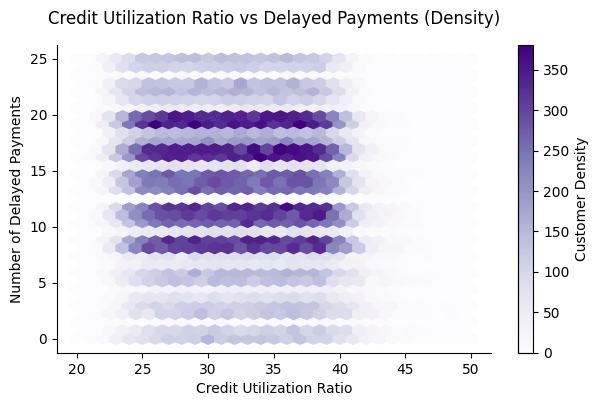

In [ ]:
# Plot density between credit utilization ratio and delayed payments

# To set a figure size
plt.figure(figsize=(7, 4))

# Create hexbin plot for density visualization
plt.hexbin(df['Credit_Utilization_Ratio'], df['Num_of_Delayed_Payment'], gridsize=30, cmap='Purples')

# Titles and axis labels
plt.title('Credit Utilization Ratio vs Delayed Payments (Density)', pad=15)
plt.xlabel('Credit Utilization Ratio')
plt.ylabel('Number of Delayed Payments')

# Add colorbar to show customer density scale
plt.colorbar(label='Customer Density')

sns.despine()

# To display the plot
plt.show()

##### Why did you pick the specific chart?

- This hexbin (density) plot helps us see the relationship between credit utilization and delayed payments clearly in a large dataset, without overlapping too many points.

##### What is/are the insight(s) found from the chart?

- Most customers are concentrated around 25–40 credit utilization ratio with 8–20 delayed payments, and there is no clear trend showing that higher utilization directly leads to more delays.

##### Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this helps Paisabazaar avoid assuming high utilization automatically means higher delay risk, but relying on utilization alone may cause wrong rejections or missed risky customers, impacting approvals and risk control

## Chart - 18
#### Correlation Heatmap

- Correlation shows how strongly two numerical variables move together (range: -1 to +1).

- **+1** (positive correlation): both variables increase together.

- **-1** (negative correlation): one increases while the other decreases.

- **0** (no correlation): no clear relationship between the two variables.

In the heatmap, darker cells = stronger correlation, lighter cells = weaker correlation.

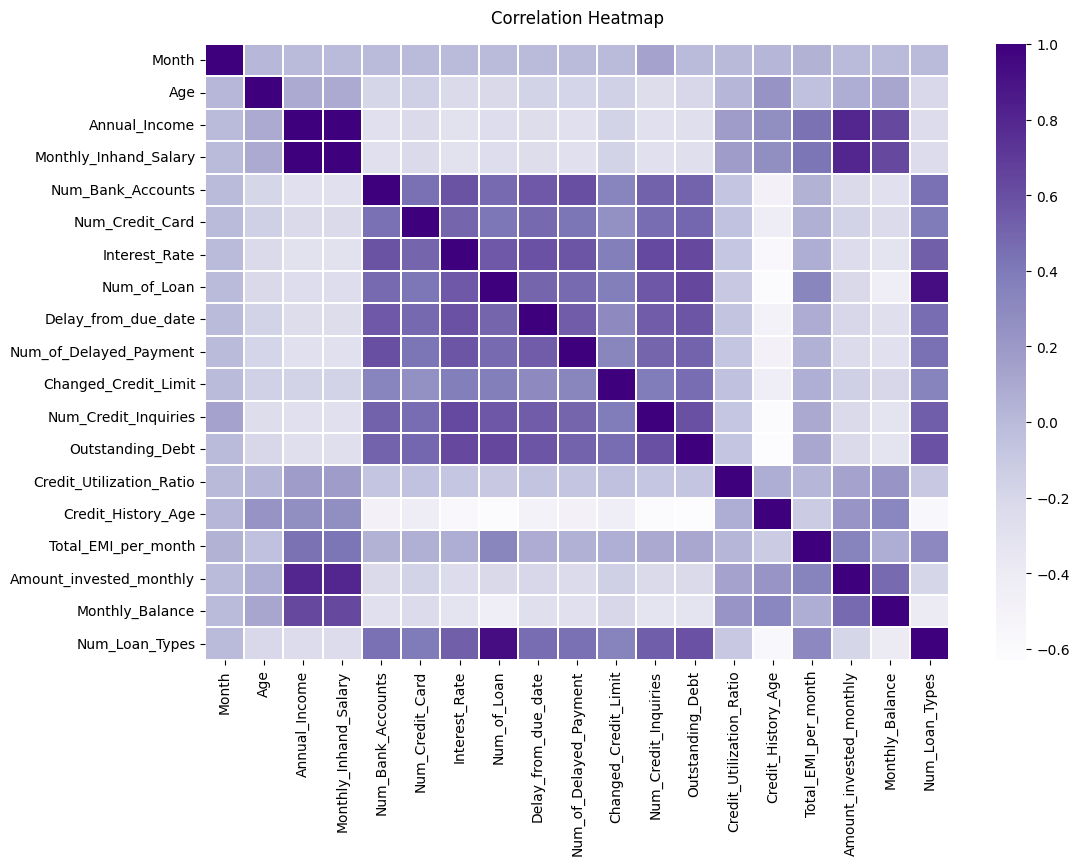

In [ ]:
# Plot correlation heatmap for numerical features

# To set a figure size
plt.figure(figsize=(12, 8))

# Select only numerical columns for correlation analysis
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[num_cols].corr()

# Create heatmap to visualize correlation between features
sns.heatmap(corr, annot=False, cmap='Purples', linewidths=0.3)

# Add title
plt.title('Correlation Heatmap', pad=15)

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- A correlation heatmap quickly highlights how numerical features are related to each other and helps detect multicollinearity before deeper analysis.

#####  What is/are the insight(s) found from the chart?

- Strong correlations are visible between similar financial variables (like income metrics), while most other features show low-to-moderate correlation, meaning customer credit behaviour is influenced by multiple factors rather than one single variable.

## Chart - 19

 ## Pair Plot

Pair plots show relationships between multiple variables at once and help visually separate patterns across credit score categories.

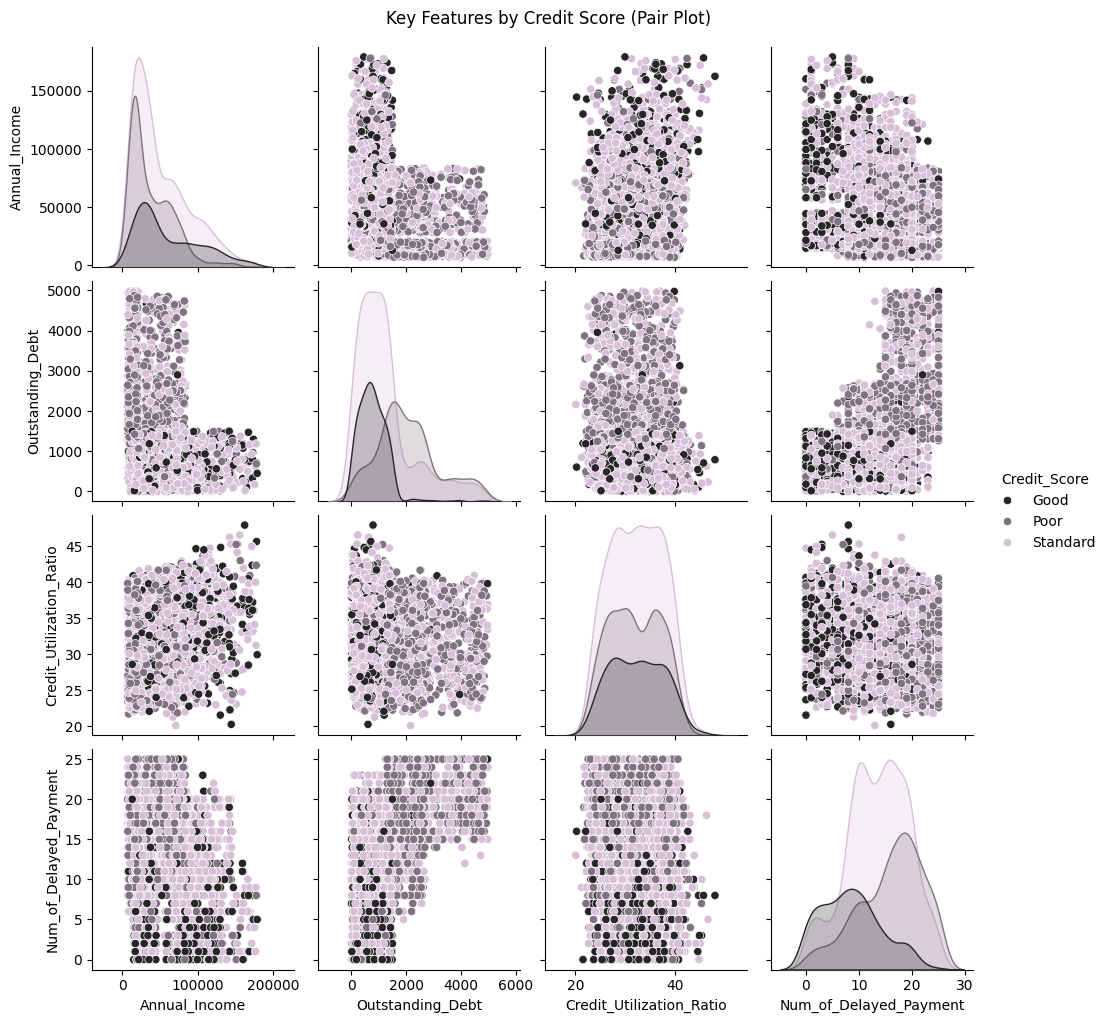

In [ ]:
# Plot pairwise relationships among key numeric variables grouped by credit score

# Select important numeric columns for pairplot analysis
pair_cols = ['Annual_Income', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Num_of_Delayed_Payment', 'Credit_Score']

# Take a sample from dataset for faster plotting
sample_df = df[pair_cols].sample(3000, random_state=42)

# Create pairplot with thistle theme
sns.pairplot(
    sample_df,
    hue='Credit_Score',
    diag_kind='kde',
    palette='dark:thistle'
)

# Add overall title
plt.suptitle('Key Features by Credit Score (Pair Plot)', y=1.02)

# To display the plot
plt.show()

#####  Why did you pick the specific chart?

- A pair plot helps compare multiple numeric features together and quickly shows which combinations best separate Good, Standard, and Poor credit score customers.

#####  What is/are the insight(s) found from the chart?

- Delayed payments and outstanding debt show the strongest visible separation across credit score categories, while income and utilization show major overlap and weaker separation.

## Chart - 20
#### Grouped Box Plot : Outstanding Debt by Credit Score & Delay Level

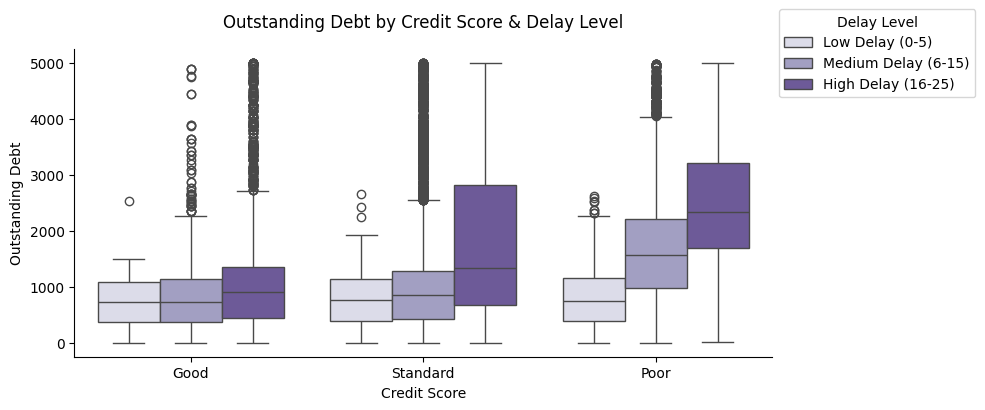

In [ ]:
# Plot outstanding debt distribution across credit score, segmented by delayed payment levels

# Create delay level categories based on number of delayed payments
df['Delay_Level'] = pd.cut(
    df['Num_of_Delayed_Payment'],
    bins=[-1, 5, 15, 25],
    labels=['Low Delay (0-5)', 'Medium Delay (6-15)', 'High Delay (16-25)']
)

# To set a figure size
plt.figure(figsize=(9, 4))

# Create boxplot to compare outstanding debt across credit scores and delay levels
sns.boxplot(
    data=df,
    x='Credit_Score',
    y='Outstanding_Debt',
    hue='Delay_Level',
    palette='Purples'
)

# Titles and axis labels
plt.title('Outstanding Debt by Credit Score & Delay Level', pad=15)
plt.xlabel('Credit Score')
plt.ylabel('Outstanding Debt')
plt.legend(title='Delay Level', loc='upper left', bbox_to_anchor=(1, 1.15))

# Using despine to remove right and top borders
sns.despine()

# To display the plot
plt.show()

##### Why did you pick the specific chart?

- This grouped boxplot helps compare debt distribution across credit score categories while also showing how delayed payment severity changes the debt risk level.

##### What is/are the insight(s) found from the chart?

- Customers with High Delay (16–25) have the highest outstanding debt, and this impact is strongest in the Poor credit score group, clearly identifying a high-risk customer segment.

##### Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Yes, this enables Paisabazaar to flag high-debt + high-delay customers for stricter risk controls and smarter approvals, reducing defaults and improving credit decision quality.

##  **Solution to Business Objective**

- Make payment behavior the primary risk signal — customers with more delayed payments and higher due-date delays consistently fall into Poor, so this should drive stricter approvals and credit limits.

- Add a “Debt Stress” check before approval — high outstanding debt + multiple loans + high utilization is the clearest pattern behind score drop, so flag these cases for manual review or risk-based pricing.

- Focus on improving the Standard segment (largest group) — use controlled limit increases + repayment nudges to move them toward Good, reducing default risk while growing revenue safely.

# **Conclusion**

- Most customers fall into the **Standard credit score category**, so improving decisions for this segment can create the biggest business impact.

- Delayed payments stand out as the clearest sign of risk, and they are much more common among customers with a Poor credit score.

- Customers carrying higher outstanding debt are more likely to have weaker credit profiles, showing that debt burden plays a major role in credit health.

- The Poor category also tends to have customers with a higher number of active loans, which increases overall credit exposure and risk.

- Credit mix is another strong differentiator — a Good credit mix is mostly seen with Good scores, while a **Bad mix** is heavily linked with Poor scores.

- Even though income matters, income alone is not a reliable indicator, because some **high-income customers** still fall into lower credit score groups due to poor credit behavior.

- Overall, the findings highlight clear drivers that can help Paisabazaar improve credit assessment consistency and provide more risk-aware product recommendations.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***